In [95]:
import gensim.downloader as api
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model = api.load("glove-wiki-gigaword-300")





Exploring Glove Wiki Api

In [96]:
#Api
len(model) #400000 unique
#print(model[0]) Vectors
print(model.index_to_key[2]) #Vocab

words = {model.index_to_key[i]: model.vectors[i] for i in range(len(model))} #Dict comprehension to match vocab and vec



.


Unsupervised Learning Methodology for Selecting Vocubulary

Pair Words to 'Credibility' Cosine Similarity

In [97]:

scores = cosine_similarity([model['credibility']], model.vectors)#Cosine of all vectors to cred
len(scores[0]) #sklearn's cosine tries to compare with a matrix so is always 2d. 

words = {model.index_to_key[i]: scores[0][i] for i in range(len(model))} #use the same syntax as before.


Threshold for Model's Most Similar Words

In [98]:
df = pd.DataFrame(words.items(), columns=['Word', 'Score']) #Dataframes are much easier to navigate 

vectors = [model[word] for word in df['Word']] #Add vectors 
df['Vector'] = vectors
df = df.sort_values('Score', ascending=False) #Scores need to be sorted to explore the closest words
df = df[df['Score'] > 0.4] #Thresholding 



AGGLOMERATIVE HIERARCHAL CLUSTERING (AHC)

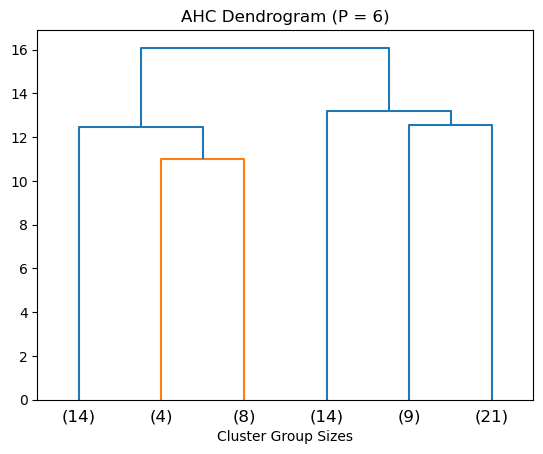

In [99]:

# Perform the necessary imports
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

x = np.array(df['Vector'].tolist()) #Scipy expects a 2d element so we need to make the list of vectors a numpy array


mergings = linkage(x, method='ward') #Instanstiates Agglomerative hierarchal clustering with the ward method

dendrogram(mergings,
           labels=df['Word'].tolist(), #flatten all the words
           truncate_mode='lastp', 
           p=6 #condense the visualisation into the biggest 3 clusters/hirearchies 
)
plt.title('AHC Dendrogram (P = 6)')
plt.xlabel('Cluster Group Sizes')
plt.show()

from scipy.cluster.hierarchy import fcluster 
df['Clusters'] = fcluster(mergings, t=6, criterion='maxclust') #fclusters actuaclly split the clusters into (in this case 3)


Human Truth Class Mapping

In [100]:
display(df['Word'].tolist())

class_map = {
    'credibility': 1,
    'legitimacy': 1,
    'undermined': 0,
    'undermine': 0,
    'reputation': 1,
    'integrity': 1,
    'doubt': 0,
    'undermining': 0,
    'undermines': 0,
    'confidence': 1,
    'doubts': 0,
    'objectivity': 1,
    'undercut': 0,
    'effectiveness': 1,
    'tarnished': 0,
    'relevance': 1,
    'fairness': 1,
    'stature': 1,
    'impartiality': 1,
    'clout': 1,
    'compromised': 0,
    'bolster': 1,
    'stability': 1,
    'prestige': 1,
    'veracity': 1,
    'questioned': 0,
    'honesty': 1,
    'viability': 1,
    'ability': 1,
    'restore': 1,
    'reputations': 1,
    'transparency': 1,
    'lacks': 0,
    'competence': 1,
    'reliability': 1,
    'doubted': 0,
    'authenticity': 1,
    'diminish': 0,
    'credentials': 1,
    'question': 0,
    'validity': 1,
    'perception': 1,
    'seriously': 0,     
    'credible': 1,
    'trustworthiness': 1,
    'tarnish': 0,
    'sincerity': 1,
    'prove': 1,
    'lend': 1,
    'erode': 0,
    'leverage': 1,
    'moral': 1,
    'damaging': 0,
    'morale': 1,
    'discredit': 0,
    'truthfulness': 1,
    'respect': 1,
    'eroding': 0,
    'compromising': 0,
    'harm': 0,
    'strength': 1,
    'commitment': 1,
    'whatever': 0,        
    'dignity': 1,
    'certainly': 1,
    'jeopardize': 0,
    'cohesion': 1,
    'lends': 1,
    'faith': 1,
    'seriousness': 1
}

#Manually map labels to top 70 words related to credibility

df['Class'] = df['Word'].map(class_map)
df

['credibility',
 'legitimacy',
 'undermined',
 'undermine',
 'reputation',
 'integrity',
 'doubt',
 'undermining',
 'undermines',
 'confidence',
 'doubts',
 'objectivity',
 'undercut',
 'effectiveness',
 'tarnished',
 'relevance',
 'fairness',
 'stature',
 'impartiality',
 'clout',
 'compromised',
 'bolster',
 'stability',
 'prestige',
 'veracity',
 'questioned',
 'honesty',
 'viability',
 'ability',
 'restore',
 'reputations',
 'transparency',
 'lacks',
 'competence',
 'reliability',
 'doubted',
 'authenticity',
 'diminish',
 'credentials',
 'question',
 'validity',
 'perception',
 'seriously',
 'credible',
 'trustworthiness',
 'tarnish',
 'sincerity',
 'prove',
 'lend',
 'erode',
 'leverage',
 'moral',
 'damaging',
 'morale',
 'discredit',
 'truthfulness',
 'respect',
 'eroding',
 'compromising',
 'harm',
 'strength',
 'commitment',
 'whatever',
 'dignity',
 'certainly',
 'jeopardize',
 'cohesion',
 'lends',
 'faith',
 'seriousness']

,Word,Score,Vector,Clusters,Class
5771,credibility,1.000000,"[0.38925, -0.16927, -0.35848, 0.0042994, 0.059...",6,1
9744,legitimacy,0.683565,"[0.53327, -0.24308, -0.045697, 0.011245, -0.06...",6,1
11103,undermined,0.631615,"[0.36091, -0.0013914, -0.33979, 0.24318, -0.01...",1,0
6530,undermine,0.608453,"[0.21453, -0.022522, -0.44462, 0.14169, -0.288...",1,0
3147,reputation,0.589866,"[0.60625, 0.018256, 0.066528, -0.059757, 0.063...",2,1
...,...,...,...,...,...
15033,jeopardize,0.407847,"[0.18355, 0.22656, -0.14056, 0.11972, -0.31887...",1,0
22476,cohesion,0.406839,"[-0.43211, 0.29653, -0.66008, 0.16595, 0.32156...",4,1
20001,lends,0.402733,"[0.040665, -0.30783, -0.0033469, -0.24966, 0.2...",3,1
2714,faith,0.402280,"[-0.18506, -0.54307, -0.40842, -0.25115, 0.150...",4,1


KMEANS and Cross-Tabulation

In [101]:
from sklearn.cluster import KMeans

#Kmeans Use for Cross Tabulation

kmeans = KMeans(n_clusters=6, random_state=42) #Same Clusters as AHC

labels = kmeans.fit_predict(x) #Fits Kmeans algorithm to the data (learns patterns) and then forms prediction

df['kmeans'] = labels #Add the kmeans labels to the  df


ct = pd.crosstab(df['kmeans'], df['Class']) #Cross Tabulation

ct = ct.rename(
    columns={0: 'Non-Credible', 1: 'Credible'}) #Rename columns 
ct


Class,Non-Credible,Credible
kmeans,,
0,0,13
1,11,2
2,3,5
3,3,9
4,5,8
5,2,9


AHC VS Human Class Visualisation

,Word,Score,Vector,Clusters,Class,kmeans
0,undermined,0.631615,"[0.36091, -0.0013914, -0.33979, 0.24318, -0.01...",1,0,1
1,undermine,0.608453,"[0.21453, -0.022522, -0.44462, 0.14169, -0.288...",1,0,4
2,undermining,0.562223,"[0.24284, 0.044908, 0.20478, 0.29666, -0.15607...",1,0,4
3,undermines,0.554237,"[0.089539, 0.080963, -0.08954, 0.079047, -0.24...",1,0,4
4,undercut,0.521325,"[0.17999, 0.19261, -0.58245, 0.21809, -0.14593...",1,0,1
...,...,...,...,...,...,...
65,credentials,0.434436,"[0.26399, 0.055283, -0.085915, 0.34622, -0.277...",6,1,2
66,validity,0.432199,"[0.30922, -0.072383, -0.41314, 0.11417, -0.628...",6,1,4
67,credible,0.429608,"[-0.16452, 0.13912, 0.13741, -0.48064, 0.10844...",6,1,4
68,prove,0.427964,"[0.33334, 0.48383, -0.42202, -0.27375, 0.16352...",6,1,1


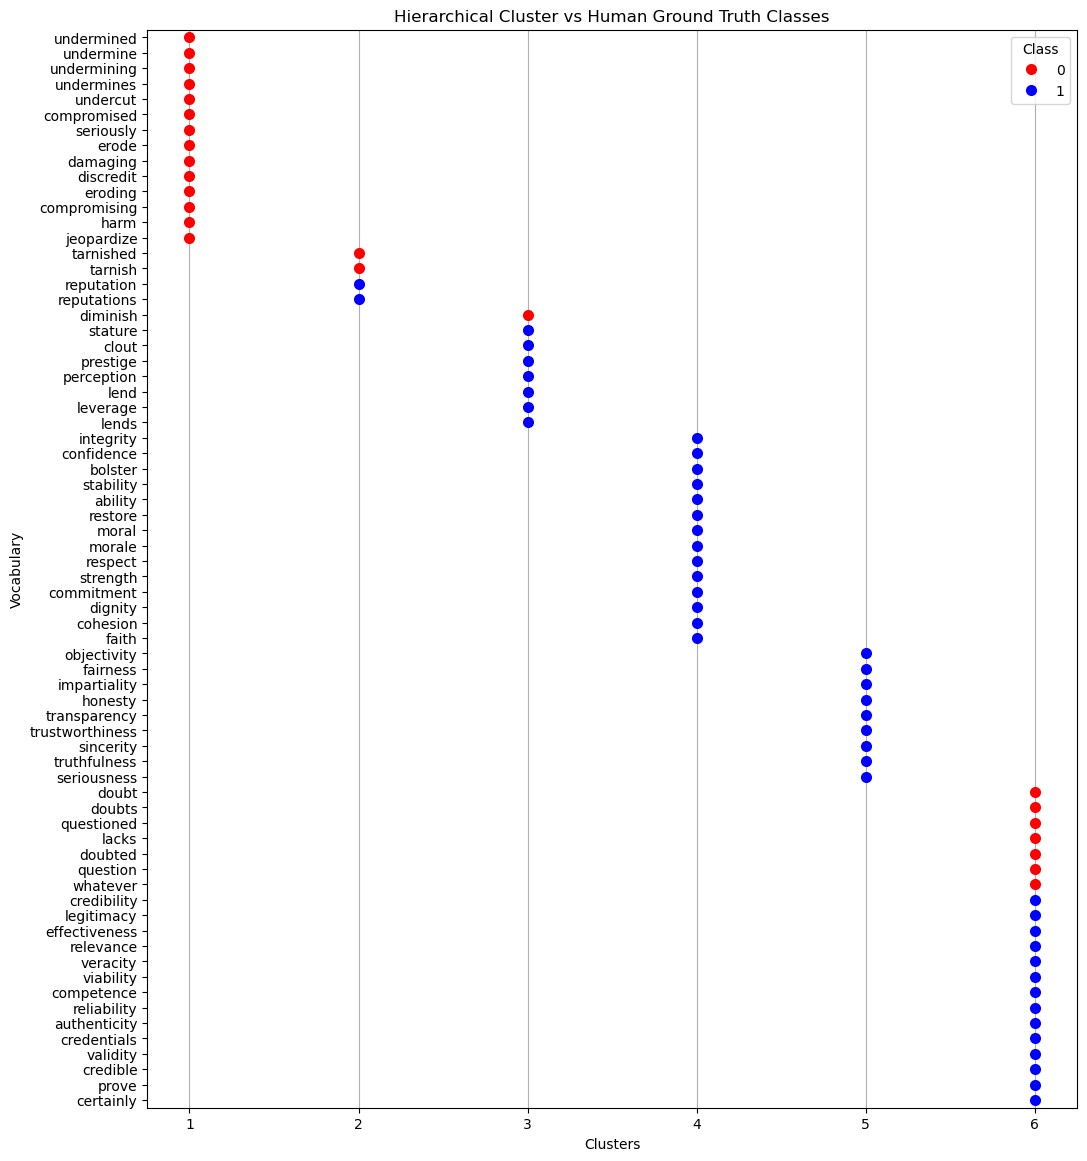

In [102]:

import seaborn as sns


df_sorted = df.sort_values(by=['Clusters', 'Class']).reset_index(drop=True) #Sort Data Frame in ascending order of cluster class for visual layout
display(df_sorted)

plt.figure(figsize=(12, 14))

ax = sns.stripplot(
    data=df_sorted,
    x='Clusters',
    y='Word',
    hue='Class', 
    palette={0: 'r', 1: 'b'}, #red and blue
    size=8

)

plt.title("Hierarchical Cluster vs Human Ground Truth Classes")
plt.xlabel("Clusters")
plt.ylabel("Vocabulary")
plt.grid(axis='x')

plt.show()

In [103]:
vec = model['biased'] 
scores = cosine_similarity([vec], model.vectors)

words = {model.index_to_key[_]: scores[0][_] for _ in range(len(model))}

df = pd.DataFrame(words.items(), columns=['Word', 'Score']) #words.items() is the key value pair - seperated into word and score column
df = df.sort_values('Score', ascending=False) #Make sure we are getting the highest scores

df = df.head(25) #Top 25
df['Score'].mean() 

#Cycled through chosen words (written below) at vec = model['...'] to look at the 25 words closest and the average similarity figure 

np.float32(0.5257373)

Credible avg = 0.56       Implausible avg = 0.67
Impartial avg = 0.58.     Partizan avg = 0.6
True = 0.64.              Untrue avg = 0.7
Honest avg = 0.61.        Dishonest avg = 0.63
Accurate avg = 0.63.      Inaccurate avg = 0.68

Text(0, 0.5, 'Vocabulary')

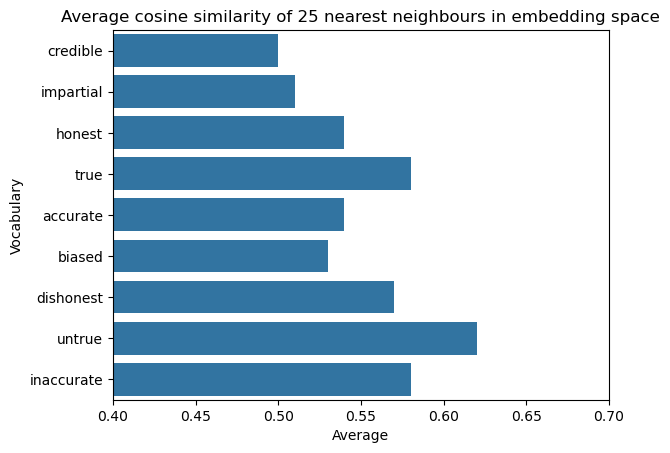

In [104]:
dict={'credible':0.50, 'impartial':0.51, 'honest':0.54,  'true':0.58, 'accurate':0.54, 'biased':0.53, 'dishonest':0.57, 'untrue':0.62,  'inaccurate':0.58 }


sns.barplot(y=dict.keys(), x=dict.values())
plt.title('Average cosine similarity of 25 nearest neighbours in embedding space')
plt.xlabel('Average')
plt.xlim(0.4, 0.7) #Xlim sets the graph range to neeten the visual
plt.ylabel('Vocabulary') #Quick barplot with manually input figures based on block above

(300,)

0.63482237


(0.4, 0.86)

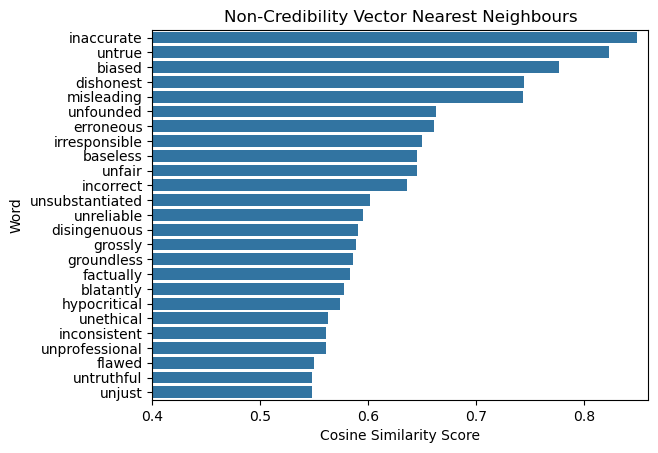

In [117]:
credible = ['true', 'honest', 'accurate', 'impartial'] 
non_credible = ['untrue', 'dishonest', 'biased', 'inaccurate']


credibility = np.mean([model[i]/ np.linalg.norm(model[i]) for i in credible], axis=0) #Axis is being specificed because the glove model is two dimentional (vector, n_dimentions)
display(model[0].shape)
noncredibility = np.mean([model[i] / np.linalg.norm(model[i]) for i in non_credible], axis=0) 

vec = noncredibility
scores = cosine_similarity([vec], model.vectors)

words = {model.index_to_key[_]: scores[0][_] for _ in range(len(model))}


df = pd.DataFrame(words.items(), columns=['Word', 'Cosine Similarity Score'])
df = df.sort_values('Cosine Similarity Score', ascending=False)

df = df.head(25)
print(df['Cosine Similarity Score'].mean())

sns.barplot(data=df, x='Cosine Similarity Score', y='Word')
plt.title('Non-Credibility Vector Nearest Neighbours')
plt.xlim(0.4, 0.86)
#Same logic as before

In [106]:
credible_words = [
    "honest",
    "accurate",
    "impartial",
    "unbiased",
    "truthful",
    "true",
    "reliable",
    "objective",
    "credible",
    "trustworthy",
    "transparent",
    "consistent",
    "fair",
    "truth",
    "straightforward",
    "thorough",
    "realistic",
    "facts",
    "reasonable",
    "correct",
    "careful",
    
]

non_credible_words = [
    "inaccurate",
    "untrue",
    "biased",
    "misleading",
    "dishonest",
    "erroneous",
    "unfounded",
    "unfair",
    "irresponsible",
    "baseless",
    "incorrect",
    "unsubstantiated",
    "unreliable",
    "disingenuous",
    "groundless",
    "hypocritical",
    "inconsistent",
    "unprofessional",
    "unethical",
    "flawed",
    "unjust",
    "untruthful"
]



j = np.mean([model[i] / np.linalg.norm(model[i]) for i in credible_words], axis=0) 
k = np.mean([model[i] / np.linalg.norm(model[i]) for i in non_credible_words], axis=0) 

axis = j-k #Axis is the difference between the two means

len(credible_words) == len(non_credible_words) #Checking if lenghths of are the same 



False

In [107]:

all_words = credible_words + non_credible_words 
scores = []

for word in all_words:

    similarity = cosine_similarity([axis], [model[word]])[0][0] #Cosine expects matricies so we pass both as matricies and then unpack them after with [0][0]
    
    scores.append(similarity) 

   
df = pd.DataFrame({
    "word": all_words,
    "score": scores
})

In [108]:
def graph(title = 'Credible Semantic Axis'):
    plt.figure(figsize=(12, 8))
    ax = sns.scatterplot(
    data=df,
    x="score",
    y="word")
    for i, row in df.iterrows(): #Iterrows lets you loop through a df row by row
        ax.annotate( 
            row["word"], #write the word 
            (row["score"], row["word"]), #xy co-ordinates for each word to be annotated on to its point
            xytext=(7, -3), #word's proximity to the point
            textcoords="offset points", #make the words show by the points
            fontsize = 8
    )
    plt.title(title)
    plt.yticks([]) #removes words from the y axis
    plt.axvline(0, linestyle="--") #Line down the center
    plt.xlim(-0.65, 0.65)
    plt.show()


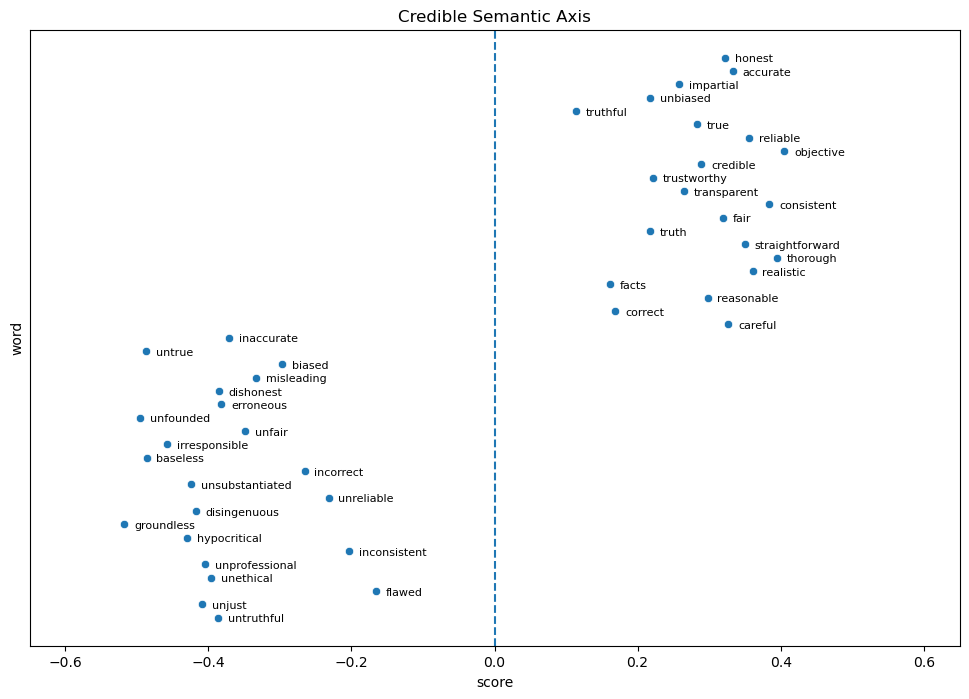

In [109]:
def add_document(df, doc_vector, doc_label,  axis):
    score = cosine_similarity([axis], [doc_vector])[0][0]
    new_row = pd.DataFrame({'word': [doc_label], 'score': score})
    return pd.concat([df, new_row], ignore_index=True)



graph()


In [110]:
axis_raw = (np.mean([model[i] for i in credible_words], axis=0) 
            - np.mean([model[i] for i in non_credible_words], axis=0))
axis_norm = axis  # your normalized version

cos_between = cosine_similarity([axis_raw], [axis_norm])[0][0]
print(cos_between)

0.9995135
